In [106]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [107]:
curr_dir_path = os.getcwd()
main_dir_path = os.path.abspath(os.path.join(curr_dir_path, os.pardir))
data_dir_path = os.path.join(main_dir_path, 'data')
raw_data_dir_path = os.path.join(data_dir_path, 'raw_data')
processed_data_dir_path = os.path.join(data_dir_path, 'processed_data')
cw_dir_path = os.path.join(data_dir_path, 'cw')
emissions_data_dir_path = os.path.join(raw_data_dir_path, 'emissions_data')
iea_data_dir_path = os.path.join(raw_data_dir_path, 'IEA_climate_policy_data')

In [108]:
IEA_policies_df = pd.read_csv(os.path.join(iea_data_dir_path, 'IEA_PAMS_Export 1_29_2025, 6_11_31 PM.csv'))
IEA_policies_df.head()

,year,jurisdiction,title,description,status,ISO3,country,topic,type,category,source
0,2011.0,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",In force,MAR,Morocco,NaN,NaN,NaN,http://www.muat.gov.ma/sites/default/files/Reg...
1,2017.0,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,In force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN,https://www.uvek.admin.ch/uvek/de/home/energie...
2,2009.0,National,Buy Smart project,"The aim of the Buy Smart""- project is to promo...",Ended,DEU,Germany,NaN,NaN,NaN,https://www.european-energy-award.de/european-...
3,2010.0,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,In force,FIN,Finland,NaN,NaN,NaN,http://www.mmm.fi/en/index/frontpage.html
4,1999.0,National,New Buses,Financial assistance to regions and municipali...,In force,ITA,Italy,NaN,NaN,NaN,NaN


In [109]:
IEA_policies_df

,year,jurisdiction,title,description,status,ISO3,country,topic,type,category,source
0,2011.0,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",In force,MAR,Morocco,NaN,NaN,NaN,http://www.muat.gov.ma/sites/default/files/Reg...
1,2017.0,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,In force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN,https://www.uvek.admin.ch/uvek/de/home/energie...
2,2009.0,National,Buy Smart project,"The aim of the Buy Smart""- project is to promo...",Ended,DEU,Germany,NaN,NaN,NaN,https://www.european-energy-award.de/european-...
3,2010.0,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,In force,FIN,Finland,NaN,NaN,NaN,http://www.mmm.fi/en/index/frontpage.html
4,1999.0,National,New Buses,Financial assistance to regions and municipali...,In force,ITA,Italy,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
13150,1996.0,National,Voluntary Energy Audits,The Grand Ducal regulation of 11 August 1996 o...,In force,LUX,Luxembourg,NaN,NaN,NaN,NaN
13151,2008.0,National,Carbon Emissions Reduction Target (Energy Effi...,The Carbon Emissions Reduction Target (CERT) -...,Ended,GBR,United Kingdom,NaN,NaN,NaN,https://www.ofgem.gov.uk/environmental-program...
13152,2009.0,National,Saving energy by the organizations of local au...,The programmes concern the implementation of i...,Ended,GRC,Greece,NaN,NaN,NaN,NaN
13153,2006.0,National,Public Transit Capital Trust,Canada's Federal Budget 2006 dedicated CAD 1.3...,In force,CAN,Canada,NaN,NaN,NaN,NaN


In [110]:
# Make all col names lowercase
IEA_policies_df.columns = IEA_policies_df.columns.str.lower()

# drop source column
IEA_policies_df = IEA_policies_df.drop(columns=['source'])

# Rename iso3 column to iso_alpha_3
IEA_policies_df.rename(columns={'iso3': 'iso_alpha_3'}, inplace=True)

## Data Integrity and Initial Cleaning

### Missing data in important columns
- year.
- iso3.

In [111]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13155 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          13127 non-null  float64
 1   jurisdiction  13155 non-null  object 
 2   title         13155 non-null  object 
 3   description   13119 non-null  object 
 4   status        13155 non-null  object 
 5   iso_alpha_3   13149 non-null  object 
 6   country       13155 non-null  object 
 7   topic         7046 non-null   object 
 8   type          7046 non-null   object 
 9   category      3630 non-null   object 
dtypes: float64(1), object(9)
memory usage: 1.0+ MB


In [112]:
# Check for duplicates
duplicates = IEA_policies_df.duplicated(keep='first')
duplicates.value_counts()

False    12739
True       416
Name: count, dtype: int64

In [113]:
# Eliminate duplicates
IEA_policies_df = IEA_policies_df.drop_duplicates()

In [114]:
# Check for NaN in year column
IEA_policies_df['year'].isnull().value_counts()

year
False    12712
True        27
Name: count, dtype: int64

In [115]:
# Print null cols where year is null
# IEA_policies_df[IEA_policies_df['year'].isnull()]

In [116]:
# For now let's drop the rows with NaN in year column
IEA_policies_df = IEA_policies_df.dropna(subset=['year'])

In [117]:
# set year column to integer
IEA_policies_df['year'] = IEA_policies_df['year'].astype(int)

In [118]:
# Check for NaN in iso3 column
IEA_policies_df['iso_alpha_3'].isnull().value_counts()

iso_alpha_3
False    12707
True         5
Name: count, dtype: int64

In [119]:
# Check the records with missing iso3
IEA_policies_df[IEA_policies_df['iso_alpha_3'].isnull()]

,year,jurisdiction,title,description,status,iso_alpha_3,country,topic,type,category
226,2013,International,Climate Technology Centre and Network Technica...,The Climate Technology Centre and Network (CTC...,In force,NaN,Unknown,NaN,NaN,NaN
229,2009,International,The World Bank Carbon Capture and Storage Capa...,"The World Bank CCS Trust Fund, established in ...",In force,NaN,Unknown,NaN,NaN,NaN
3325,2015,International,The Vatican’s Laudato Si’ Action Platform,Pope Francis issued the Laudato Si’ encyclical...,In force,NaN,Vatican City,People-Centred Clean Energy Transitions,"Socioeconomic development,,Public participation,",NaN
3342,2008,National,Vatican installation of PV system,"To help green its operations, as promoted by P...",In force,NaN,Vatican City,People-Centred Clean Energy Transitions,"Energy security and resilience,,Public partici...",NaN
5019,2019,International,LEAP-RE,LEAP-RE is a mechanism for funding R&amp;D and...,In force,NaN,African Union,Technology R&D and innovation,"Grants,Resource push",Grants for R&D projects


In [120]:
# Drop rows with NaN in iso3 column
IEA_policies_df = IEA_policies_df.dropna(subset=['iso_alpha_3'])

In [121]:
# Check jurisdiction column
IEA_policies_df['jurisdiction'].unique()

array(['National', 'City/Municipal', 'State/Provincial', 'International',
       'Unknown', 'Other', 'Regional', 'National '], dtype=object)

In [122]:
# Replace the 'National ' values to 'National' in the jurisdiction column
IEA_policies_df.loc[IEA_policies_df['jurisdiction'] == 'National ', 'jurisdiction'] = 'National'

In [123]:
IEA_policies_df['jurisdiction'].unique()

array(['National', 'City/Municipal', 'State/Provincial', 'International',
       'Unknown', 'Other', 'Regional'], dtype=object)

In [124]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12707 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          12707 non-null  int64 
 1   jurisdiction  12707 non-null  object
 2   title         12707 non-null  object
 3   description   12672 non-null  object
 4   status        12707 non-null  object
 5   iso_alpha_3   12707 non-null  object
 6   country       12707 non-null  object
 7   topic         6636 non-null   object
 8   type          6636 non-null   object
 9   category      3294 non-null   object
dtypes: int64(1), object(9)
memory usage: 1.1+ MB


In [125]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12707 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          12707 non-null  int64 
 1   jurisdiction  12707 non-null  object
 2   title         12707 non-null  object
 3   description   12672 non-null  object
 4   status        12707 non-null  object
 5   iso_alpha_3   12707 non-null  object
 6   country       12707 non-null  object
 7   topic         6636 non-null   object
 8   type          6636 non-null   object
 9   category      3294 non-null   object
dtypes: int64(1), object(9)
memory usage: 1.1+ MB


In [126]:
# Fill NaNs with Unknown
# IEA_policies_df = IEA_policies_df.fillna('Unknown')

## Understanding the Data

- Num of regions: 217


In [127]:
# How many countries we have?
IEA_policies_df['country'].nunique()

217

In [128]:
# How many policies each country has?
policies_per_country_df = IEA_policies_df['country'].value_counts().reset_index()
policies_per_country_df.columns = ['country', 'policy_count']
policies_per_country_df

,country,policy_count
0,United States,759
1,Australia,468
2,Canada,436
3,People's Republic of China,397
4,United Kingdom,347
...,...,...
212,British Indian Ocean Territory,1
213,Netherlands Antilles,1
214,French Guiana,1
215,Western Sahara,1


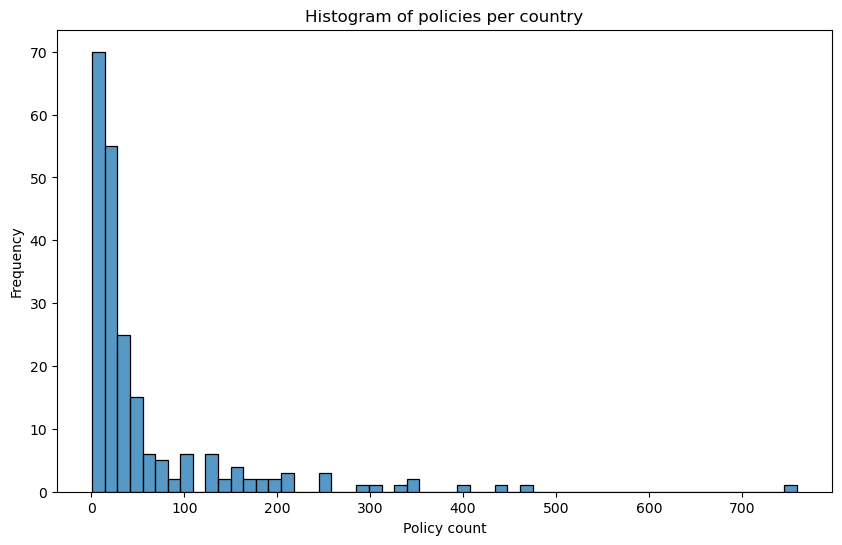

In [129]:
# Histogram of policies per country
plt.figure(figsize=(10, 6))
sns.histplot(policies_per_country_df['policy_count'])
plt.title('Histogram of policies per country')
plt.xlabel('Policy count')
plt.ylabel('Frequency')
plt.show()


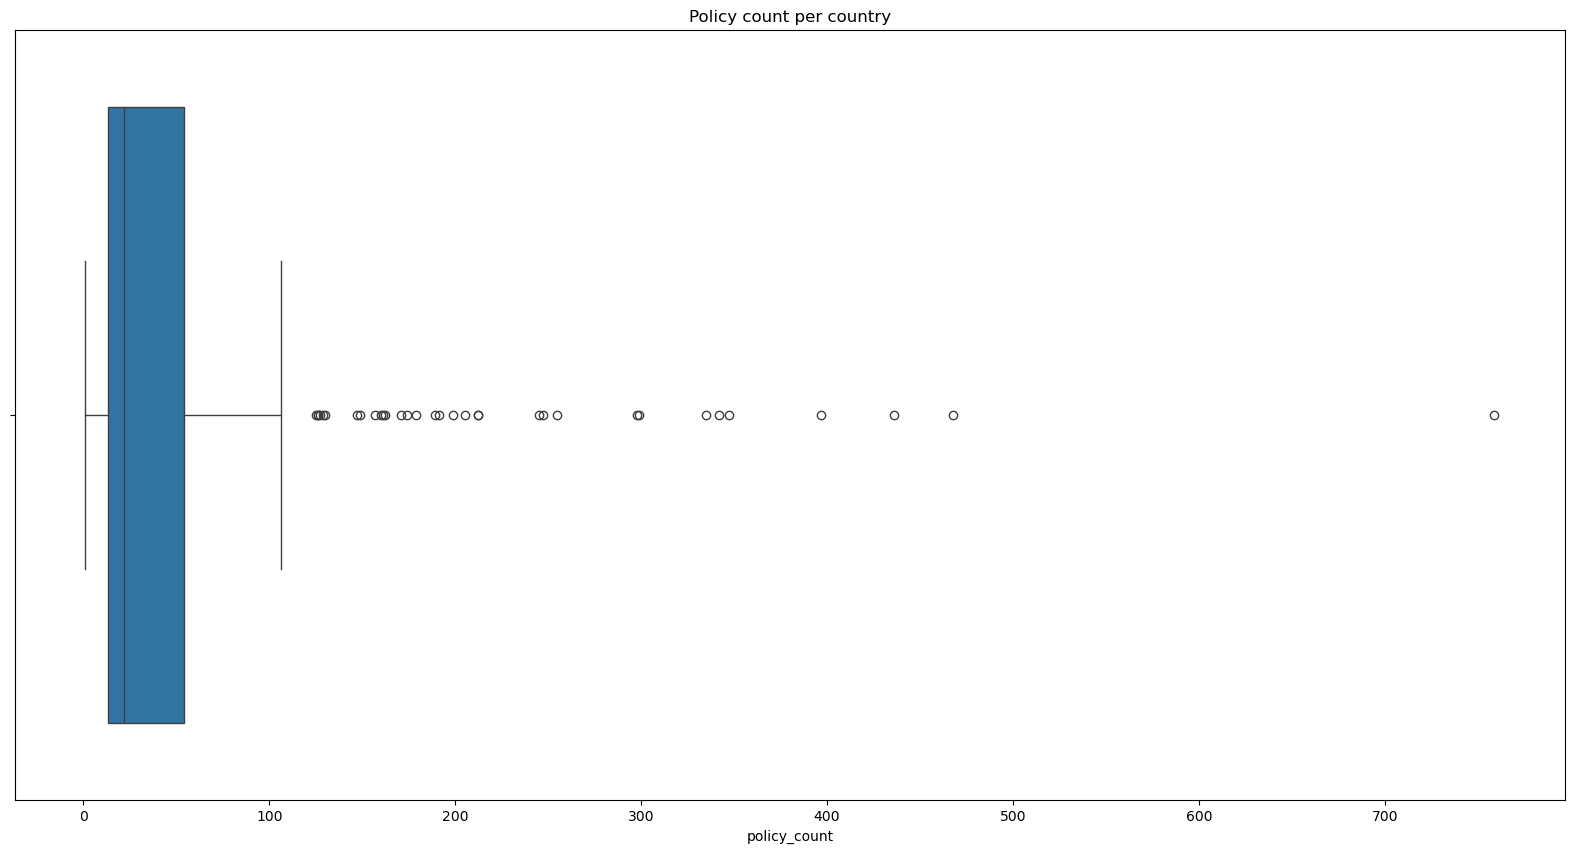

In [130]:
# Boxplot of policy count per country
plt.figure(figsize=(20, 10))
sns.boxplot(data=policies_per_country_df, x='policy_count')
plt.title('Policy count per country')
plt.show()

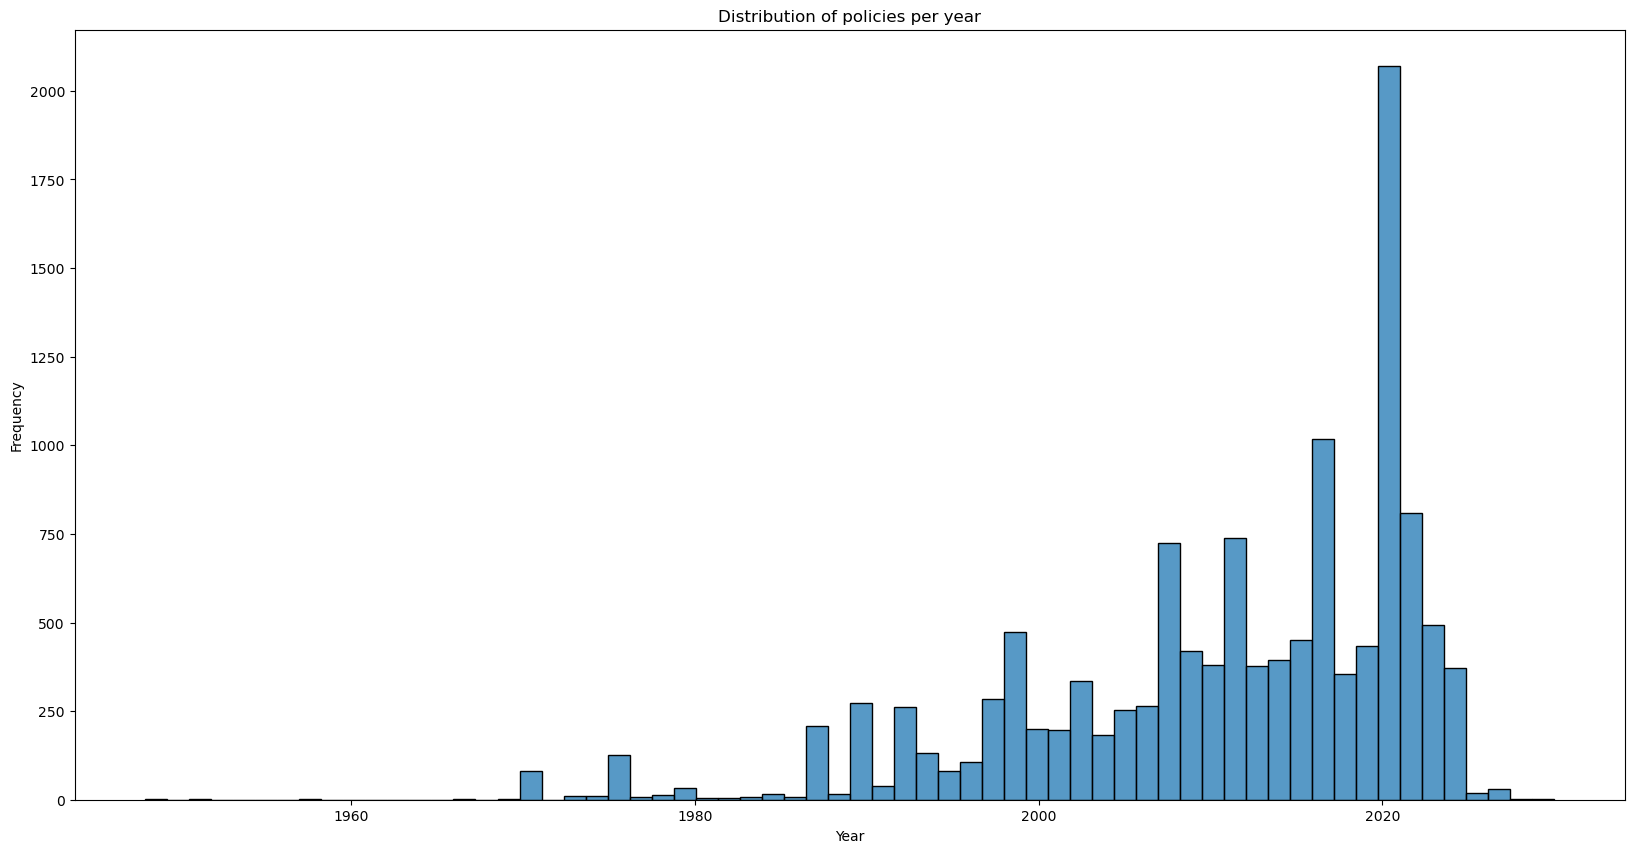

In [131]:
# Check the distribution of policies per year
plt.figure(figsize=(20, 10))
sns.histplot(IEA_policies_df['year'])
plt.title('Distribution of policies per year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

In [132]:
IEA_policies_df.columns

Index(['year', 'jurisdiction', 'title', 'description', 'status', 'iso_alpha_3',
       'country', 'topic', 'type', 'category'],
      dtype='object')

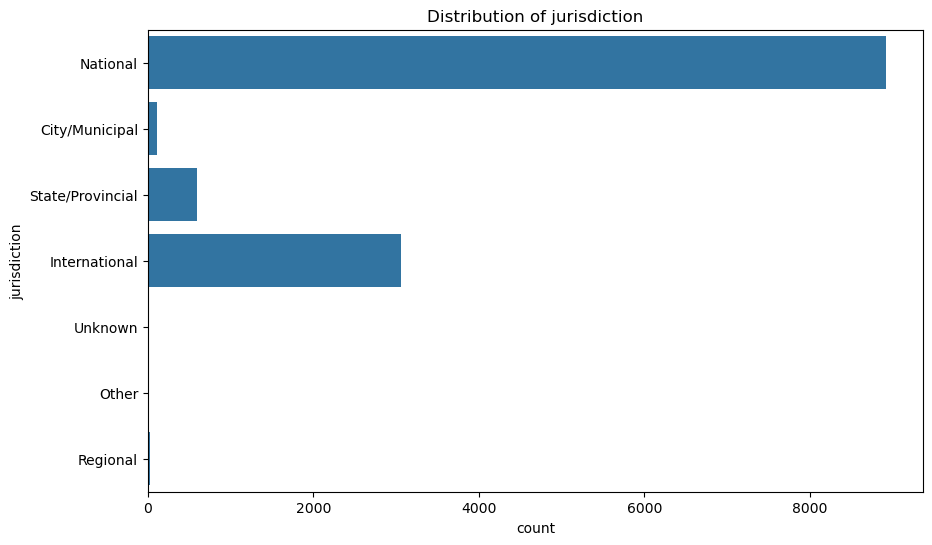

In [133]:
# Plot distribution of jurisdiction
plt.figure(figsize=(10, 6))
sns.countplot(data=IEA_policies_df, y='jurisdiction')
plt.title('Distribution of jurisdiction')
plt.show()

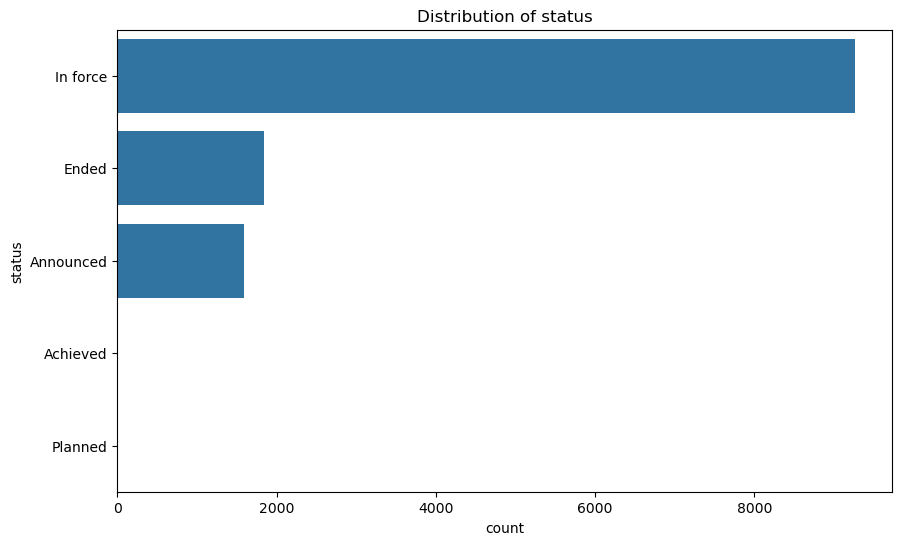

In [134]:
# Plot distribution of status
plt.figure(figsize=(10, 6))
sns.countplot(data=IEA_policies_df, y='status')
plt.title('Distribution of status')
plt.show()


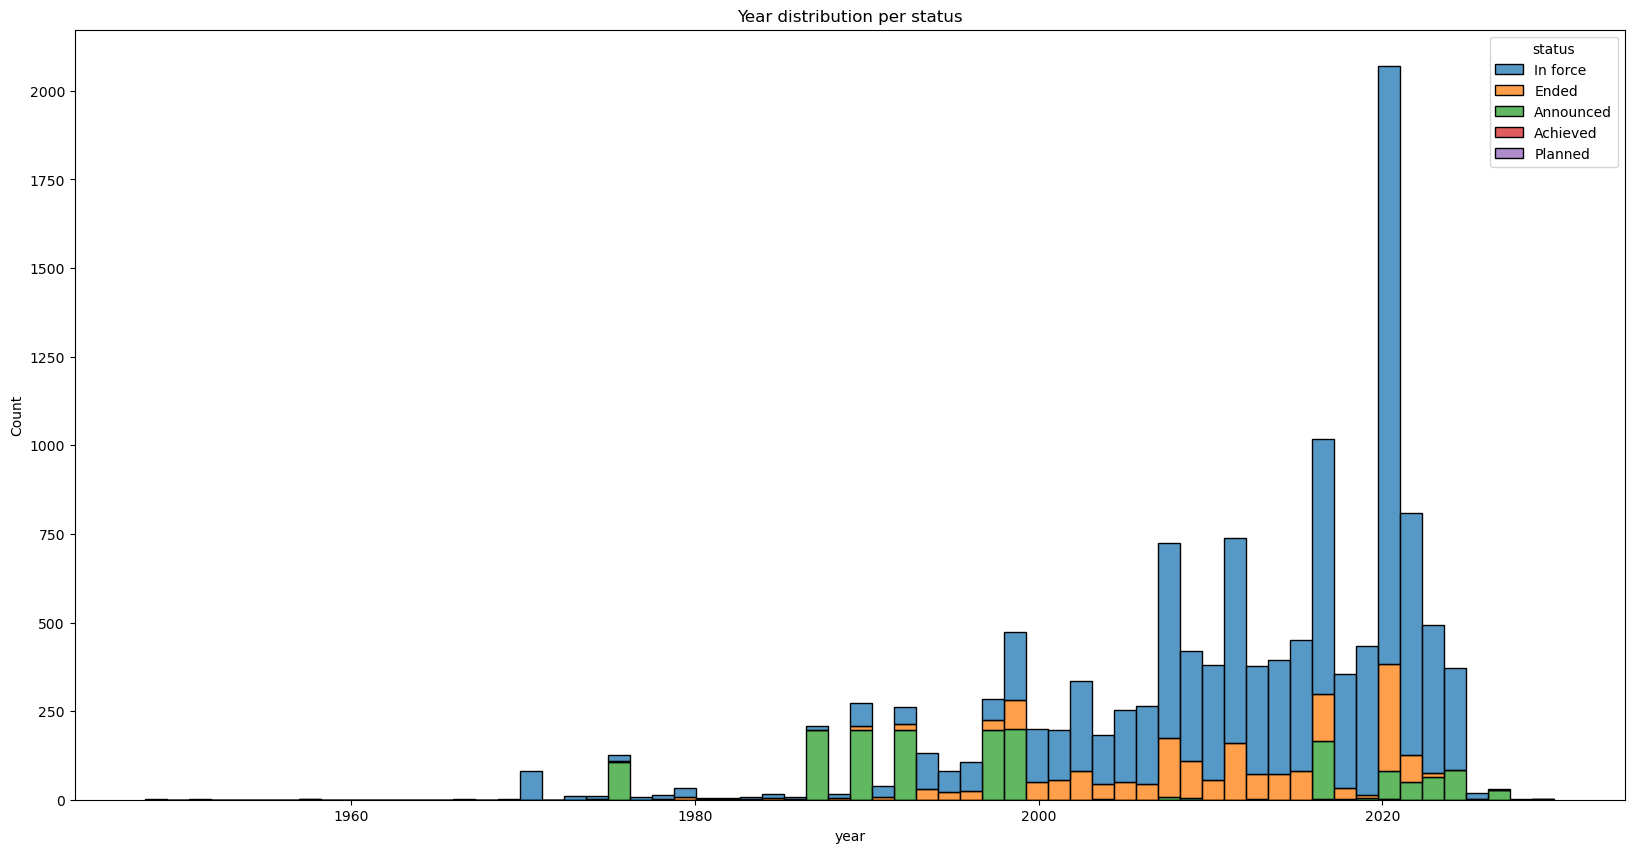

In [135]:
# Plot year distribution per status
plt.figure(figsize=(20, 10))
sns.histplot(data=IEA_policies_df, x='year', hue='status', multiple='stack')
plt.title('Year distribution per status')
plt.show()

In [137]:
IEA_policies_df["category"].unique()

array([nan, 'Light-duty vehicles',
       'Information campaigns (including information about new technologies),Grants for R&D projects,Technology showcases and events',
       'Grants for demonstration projects,Grants for R&D projects',
       'Connecting innovators and testers,Expert platforms to inform government',
       'Oil and natural gas extraction', 'Heat pumps,Air conditioners',
       'Light-duty vehicles,Batteries', 'Solar PVs', '2-/3-wheelers',
       'Hydro', 'Existing buildings,Hydro', 'Other', 'Batteries',
       'Aircrafts', 'R&D tax incentives', 'Emission Trading System (ETS)',
       'New buildings', 'Existing buildings', 'Air conditioners',
       'Medium/Heavy-duty vehicles', 'Urban transit',
       'Grants for R&D projects,Grants for R&D projects (co-funded by more than one government)',
       'Grants for R&D projects',
       'Disclosure rules in funding agreements,Grants for demonstration projects',
       'Investment in third party equity fund for start-ups', 

## Create Feature dataset

NOTES:

- Title and Desciption fields are complete so we can use them for an NLP to obtain the type of policy and thus assign a weight to it.
- Jurisdiction is also very complete so we can use it to also add a weight to de policy.
- Using only in force policies and doing a cumulative sum might be the simplest way to start playing with this data.

In [103]:
IEA_policies_df.status.unique()

array(['In force', 'Ended', 'Announced', 'Achieved', 'Planned'],
      dtype=object)

In [104]:
# Filter out the policies that have a status of 'Announced', 'Planned'
IEA_policies_df = IEA_policies_df[IEA_policies_df['status'] == "In force"]
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9268 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          9268 non-null   int64 
 1   jurisdiction  9268 non-null   object
 2   title         9268 non-null   object
 3   description   9259 non-null   object
 4   status        9268 non-null   object
 5   iso_alpha_3   9268 non-null   object
 6   country       9268 non-null   object
 7   topic         4632 non-null   object
 8   type          4632 non-null   object
 9   category      2891 non-null   object
dtypes: int64(1), object(9)
memory usage: 796.5+ KB


In [139]:
IEA_policies_df.jurisdiction.unique()

array(['National', 'City/Municipal', 'State/Provincial', 'International',
       'Unknown', 'Other', 'Regional'], dtype=object)

In [138]:
IEA_policies_df.to_csv(os.path.join(processed_data_dir_path, 'IEA_policies_clean.csv'), index=False)